## Model Compression baseline

The purpose of this notebook is to define baseline compression strategies. These strategies will be compared to advanced personalized compression strategies in the thesis to determine their usefulness.

setup

In [1]:
from dataclasses import replace
from datetime import datetime, timezone
import json
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

In [2]:
def find_project_root(start):
    start = start.resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'mlp_replacement').is_dir():
            return candidate
    raise RuntimeError('Could not locate the repository root')

In [3]:
PROJECT_ROOT = find_project_root(Path.cwd())
SRC = PROJECT_ROOT / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from mlp_replacement.config import (
    CaptureConfig,
    DataConfig,
    ExperimentConfig,
    ModelConfig,
    OperatorConfig,
    RecoveryConfig,
    SelectionConfig,
    WorkflowConfig,
)
from mlp_replacement.data import (
    DataLoaders,
    build_data_loaders,
    contiguous_token_windows,
    load_text_dataset,
    make_token_loader,
    sample_partitioned_windows,
)
from mlp_replacement.evaluation.footprint import (
    parameter_footprint,
    serialized_checkpoint_bytes,
)
from mlp_replacement.evaluation.language_model import (
    evaluate_language_model,
)
from mlp_replacement.model import (
    discover_mlp_blocks,
    load_model_and_tokenizer,
)
from mlp_replacement.runlog import environment_record, json_value
from mlp_replacement.compression.selection import select_layers
from mlp_replacement.compression.workflows import run_replacement_experiment

In [4]:
SEED = 21
torch.manual_seed(SEED)
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
EXECUTION_MODE = 'load'
RUN_FROM_SCRATCH = EXECUTION_MODE == 'run'
loaded_artifact = None

SWIGLU_WIDTH_RATIO = 0.50
INTERLEAVE_STRIDE = 2
INTERLEAVE_OFFSET = 0
RECOVERY_BATCHES = 64
SAVE_COMPRESSED_MODEL = False
COMPRESSED_MODEL_ROOT = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'compressed-models'
    / 'interleaved-swiglu-050'
)
COMPRESSED_MODEL_PATHS = {
    'including_boundaries': (
        COMPRESSED_MODEL_ROOT / 'including-boundaries'
    ),
    'excluding_boundaries': (
        COMPRESSED_MODEL_ROOT / 'excluding-boundaries'
    ),
}
ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'model-compression-baselines'
    / 'compression-baseline.json'
)

In [6]:
model_config = ModelConfig(
    model_id='HuggingFaceTB/SmolLM2-1.7B',
    device='auto',
    dtype='auto',
)

data_config = DataConfig(
    sequence_length=128,
    batch_size=2,
    num_calibration_batches=48,
    num_operator_validation_batches=24,
    num_recovery_batches=RECOVERY_BATCHES,
    num_recovery_validation_batches=24,
    num_model_validation_batches=24,
    num_test_batches=0,
    seed=SEED,
)

selection_including_boundaries = SelectionConfig(
    strategy='interleaved',
    interleave_stride=INTERLEAVE_STRIDE,
    interleave_offset=INTERLEAVE_OFFSET,
    protected_prefix=0,
    protected_suffix=0,
    application_order='layer',
    seed=SEED,
)

selection_excluding_boundaries = SelectionConfig(
    strategy='interleaved',
    interleave_stride=INTERLEAVE_STRIDE,
    interleave_offset=INTERLEAVE_OFFSET,
    protected_prefix=1,
    protected_suffix=1,
    application_order='layer',
    seed=SEED,
)

operator_config = OperatorConfig(
    kind='swiglu',
    intermediate_ratio=SWIGLU_WIDTH_RATIO,
    bias=False,
    epochs=64,
    learning_rate=1e-3,
    batch_size=2048,
    weight_decay=0.0,
    scheduler='constant',
    early_stopping_patience=3,
    seed=SEED,
)

recovery_config = RecoveryConfig(
    enabled=True,
    epochs=1,
    learning_rate=1e-5,
    weight_decay=0.0,
    temperature=1.0,
    cache_dtype='float16',
    early_stopping_patience=None,
)

capture_config = CaptureConfig(
    storage_device='cpu',
    storage_dtype='float32',
)
workflow_config = WorkflowConfig(strategy='one_shot')

experiment_configs = {
    'including_boundaries': ExperimentConfig(
        model=model_config,
        data=data_config,
        capture=capture_config,
        selection=selection_including_boundaries,
        operator=operator_config,
        recovery=recovery_config,
        workflow=workflow_config,
    ),
    'excluding_boundaries': ExperimentConfig(
        model=model_config,
        data=data_config,
        capture=capture_config,
        selection=selection_excluding_boundaries,
        operator=operator_config,
        recovery=recovery_config,
        workflow=workflow_config,
    ),
}

In [7]:
if RUN_FROM_SCRATCH:
    model, tokenizer = load_model_and_tokenizer(model_config)
    device = next(model.parameters()).device
else:
    loaded_artifact = json.loads(
        ARTIFACT_PATH.read_text(encoding='utf-8')
    )

In [8]:
if RUN_FROM_SCRATCH:
    loaders = build_data_loaders(
        tokenizer,
        data_config,
        include_recovery=True,
    )

### Initial evaluation

In [9]:
if RUN_FROM_SCRATCH:
    mlp_blocks = discover_mlp_blocks(model)
    available_layers = [block.index for block in mlp_blocks]
    selection_previews = {
        name: select_layers(
            available_layers,
            config.selection,
        )
        for name, config in experiment_configs.items()
    }
    initial_footprint = parameter_footprint(model)
    initial_metrics = evaluate_language_model(
        model,
        loaders.model_validation,
        device,
        data_config.num_model_validation_batches,
    )

    initial_evaluation = pd.DataFrame([{
        'variant': 'dense_reference',
        'stage': 'initial',
        'selected_layers': [],
        'parameters': initial_footprint.parameters,
        'trainable_parameters': (
            initial_footprint.trainable_parameters
        ),
        'theoretical_weight_bytes': (
            initial_footprint.theoretical_weight_bytes
        ),
        'removed_parameters': 0,
        'parameter_reduction_pct': 0.0,
        'teacher_kl': 0.0,
        'loss': initial_metrics.loss,
        'perplexity': initial_metrics.perplexity,
        'predicted_tokens': initial_metrics.predicted_tokens,
        'batches': initial_metrics.batches,
    }])
    selection_summary = pd.DataFrame([
        {
            'variant': name,
            'eligible_blocks': len(selection.eligible_indices),
            'selected_blocks': len(selection.indices),
            'selected_layers': list(selection.indices),
        }
        for name, selection in selection_previews.items()
    ])
else:
    initial_evaluation = pd.DataFrame(
        loaded_artifact['results']['evaluations']
    ).query("variant == 'dense_reference'").reset_index(drop=True)
    selection_summary = pd.DataFrame(
        loaded_artifact['results']['selections']
    )

display(initial_evaluation)
display(selection_summary)

,variant,stage,selected_layers,parameters,trainable_parameters,theoretical_weight_bytes,removed_parameters,parameter_reduction_pct,teacher_kl,loss,perplexity,predicted_tokens,batches
0,dense_reference,initial,[],1711376384,1711376384,3422752768,0,0.0,0.0,2.669973,14.439586,6096,24


,variant,eligible_blocks,selected_blocks,selected_layers
0,including_boundaries,24,12,"[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]"
1,excluding_boundaries,22,11,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]"


## Experiments

### Uniform Compression baselines

1. Interleaved swiGLU replacement:
    - replace every second block of the model with selected operator (e.g. swiGLU 0.50)
    - KD retrain

2. BI-score guided k-block replacement:
    - extension of mvp
    - test BI/MLP-score
    - approach:
        1. select target model % sparsity = s
        2. redistribute uniform operator capacity based on s -> number of replaced blocks k
        3. replace top/bottom k blocks
        4. KD retrain


constraints:
- exclusion of transformer first and last block

#### Interleaved swiGLU

In [10]:
interleaved_results = {}
serialized_model_bytes_by_variant = {}

for run_index, (variant, config) in enumerate(
    experiment_configs.items() if RUN_FROM_SCRATCH else []
):
    if run_index > 0:
        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        model, _ = load_model_and_tokenizer(model_config)

    interleaved_results[variant] = run_replacement_experiment(
        model,
        loaders,
        config,
    )

    serialized_model_bytes_by_variant[variant] = None
    if SAVE_COMPRESSED_MODEL:
        output_path = COMPRESSED_MODEL_PATHS[variant]
        model.save_pretrained(output_path)
        tokenizer.save_pretrained(output_path)
        serialized_model_bytes_by_variant[variant] = (
            serialized_checkpoint_bytes(output_path)
        )

In [11]:
compressed_rows = []
block_rows = []

for variant, result in interleaved_results.items():
    removed_parameters = (
        result.footprint_before.parameters
        - result.footprint_after.parameters
    )
    parameter_reduction_pct = (
        100
        * removed_parameters
        / result.footprint_before.parameters
    )
    stages = (
        (
            'before_recovery',
            result.pre_recovery_validation_metrics,
            result.pre_recovery_validation_kl,
        ),
        (
            'after_recovery',
            result.final_validation_metrics,
            result.post_recovery_validation_kl,
        ),
    )

    for stage, metrics, teacher_kl in stages:
        compressed_rows.append({
            'variant': variant,
            'stage': stage,
            'selected_layers': list(result.selection.indices),
            'parameters': result.footprint_after.parameters,
            'trainable_parameters': (
                result.footprint_after.trainable_parameters
            ),
            'theoretical_weight_bytes': (
                result.footprint_after.theoretical_weight_bytes
            ),
            'removed_parameters': removed_parameters,
            'parameter_reduction_pct': parameter_reduction_pct,
            'teacher_kl': teacher_kl,
            'loss': metrics.loss,
            'perplexity': metrics.perplexity,
            'predicted_tokens': metrics.predicted_tokens,
            'batches': metrics.batches,
        })

    for block in result.blocks:
        block_rows.append({
            'variant': variant,
            'layer': block.layer_index,
            'original_parameters': block.original_parameters,
            'replacement_parameters': block.replacement_parameters,
            'retained_pct': (
                100
                * block.replacement_parameters
                / block.original_parameters
            ),
            'validation_mse': block.operator_validation_mse,
            'best_epoch': block.best_operator_epoch,
        })

if RUN_FROM_SCRATCH:
    compressed_evaluation = pd.DataFrame(
        compressed_rows,
        columns=initial_evaluation.columns,
    )
    evaluation_summary = pd.concat(
        [initial_evaluation, compressed_evaluation],
        ignore_index=True,
    )
    block_summary = pd.DataFrame(block_rows)
else:
    evaluation_summary = pd.DataFrame(
        loaded_artifact['results']['evaluations']
    )
    compressed_evaluation = evaluation_summary.query(
        "variant != 'dense_reference'"
    ).reset_index(drop=True)
    block_summary = pd.DataFrame(
        loaded_artifact['results']['block_fitting']
    )

display(evaluation_summary)
display(block_summary)

,variant,stage,selected_layers,parameters,trainable_parameters,theoretical_weight_bytes,removed_parameters,parameter_reduction_pct,teacher_kl,loss,perplexity,predicted_tokens,batches
0,dense_reference,initial,[],1711376384,1711376384,3422752768,0,0.000000,0.000000,2.669973,1.443959e+01,6096,24
1,including_boundaries,before_recovery,"[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]",1409386496,1409386496,2818772992,301989888,17.646024,14.627843,17.654531,4.647990e+07,6096,24
2,including_boundaries,after_recovery,"[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22]",1409386496,1409386496,2818772992,301989888,17.646024,13.319576,14.827358,2.750678e+06,6096,24
3,excluding_boundaries,before_recovery,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]",1434552320,1434552320,2869104640,276824064,16.175522,2.966435,6.190840,4.882558e+02,6096,24
4,excluding_boundaries,after_recovery,"[1, 3, 5, 7, 9, 11, 13, 15, 17, 19, 21]",1434552320,1434552320,2869104640,276824064,16.175522,1.674140,5.204122,1.820211e+02,6096,24


,variant,layer,original_parameters,replacement_parameters,retained_pct,validation_mse,best_epoch
0,including_boundaries,0,50331648,25165824,50.0,0.051245,64
1,including_boundaries,2,50331648,25165824,50.0,0.152653,44
2,including_boundaries,4,50331648,25165824,50.0,0.307208,38
3,including_boundaries,6,50331648,25165824,50.0,0.493018,35
4,including_boundaries,8,50331648,25165824,50.0,0.876719,41
5,including_boundaries,10,50331648,25165824,50.0,1.004025,45
6,including_boundaries,12,50331648,25165824,50.0,1.064269,44
7,including_boundaries,14,50331648,25165824,50.0,1.571612,52
8,including_boundaries,16,50331648,25165824,50.0,4.091588,53
9,including_boundaries,18,50331648,25165824,50.0,11.959154,57


In [12]:
serialization_summary = (
    pd.DataFrame([
        {
            'variant': variant,
            'compressed_model_path': (
                str(COMPRESSED_MODEL_PATHS[variant])
                if SAVE_COMPRESSED_MODEL
                else None
            ),
            'serialized_model_bytes': serialized_bytes,
        }
        for variant, serialized_bytes
        in serialized_model_bytes_by_variant.items()
    ])
    if RUN_FROM_SCRATCH
    else pd.DataFrame(
        loaded_artifact['results']['serialization']
    )
)

display(serialization_summary)

,variant,compressed_model_path,serialized_model_bytes
0,including_boundaries,None,None
1,excluding_boundaries,None,None


In [13]:
def json_records(frame):
    return json.loads(
        frame.to_json(orient='records', double_precision=15)
    )


if RUN_FROM_SCRATCH:
    artifact = {
        'schema_version': 1,
        'created_at_utc': datetime.now(timezone.utc).isoformat(),
        'environment': environment_record(),
        'configuration': {
            'model': {
                **json_value(model_config),
                'resolved_revision': getattr(
                    model.config,
                    '_commit_hash',
                    None,
                ),
            },
            'experiments': {
                variant: config.to_dict()
                for variant, config in experiment_configs.items()
            },
            'save_compressed_model': SAVE_COMPRESSED_MODEL,
            'compressed_model_paths': COMPRESSED_MODEL_PATHS,
        },
        'results': {
            'evaluations': json_records(evaluation_summary),
            'selections': json_records(selection_summary),
            'block_fitting': json_records(block_summary),
            'serialization': json_records(serialization_summary),
            'workflows': json_value(interleaved_results),
        },
    }

    ARTIFACT_PATH.parent.mkdir(parents=True, exist_ok=True)
    ARTIFACT_PATH.write_text(
        json.dumps(json_value(artifact), indent=2, allow_nan=False),
        encoding='utf-8',
    )
    print(f'Saved compression baseline artifact to {ARTIFACT_PATH}')
else:
    artifact = loaded_artifact
    print(f'Loaded compression baseline artifact from {ARTIFACT_PATH}')

Loaded compression baseline artifact from /home/sgulas/thesis/development/data/results/model-compression-baselines/compression-baseline.json


## Optimized Run

This section contains experiments replication using the newly defined calibration data loading + operator initialization from teacher weights.

configuration:
- 50% swiGLU
- interleaved
- including/excluding boundary blocks (first, last)

setup

In [14]:
OPTIMIZED_EXECUTION_MODE = 'run'
RUN_OPTIMIZED_FROM_SCRATCH = (
    OPTIMIZED_EXECUTION_MODE == 'run'
)
OPTIMIZED_ARTIFACT_SCHEMA_VERSION = 2
OPTIMIZED_ARTIFACT_PATH = (
    PROJECT_ROOT
    / 'data'
    / 'results'
    / 'model-compression-baselines'
    / 'compression-baseline-v2.json'
)
optimized_artifact = (
    None
    if RUN_OPTIMIZED_FROM_SCRATCH
    else json.loads(
        OPTIMIZED_ARTIFACT_PATH.read_text(encoding='utf-8')
    )
)
if (
    not RUN_OPTIMIZED_FROM_SCRATCH
    and optimized_artifact.get('schema_version')
    != OPTIMIZED_ARTIFACT_SCHEMA_VERSION
):
    raise ValueError(
        'The optimized artifact uses an incompatible schema.'
    )

In [15]:
BASE_CALIBRATION_BATCHES = data_config.num_calibration_batches
OPTIMIZED_CALIBRATION_BATCHES = 384
ADDITIONAL_CALIBRATION_BATCHES = (
    OPTIMIZED_CALIBRATION_BATCHES - BASE_CALIBRATION_BATCHES
)
OPTIMIZED_METHODOLOGIES = {
    'new_data_random': 'random_weights',
    'complete_method': 'importance_teacher_subset',
}
OPTIMIZED_SELECTION_VARIANTS = (
    'including_boundaries',
    'excluding_boundaries',
)

In [16]:
historical_model_revision = artifact['configuration'][
    'model'
].get('resolved_revision')
if historical_model_revision is None:
    raise ValueError(
        'Historical artifact does not record a model revision'
    )
historical_tokenizer_revision = (
    artifact['configuration']['model'].get(
        'tokenizer_revision'
    )
    or historical_model_revision
)
optimized_model_config = replace(
    model_config,
    revision=historical_model_revision,
    tokenizer_revision=historical_tokenizer_revision,
)
optimized_data_config = DataConfig(
    calibration_source=data_config.calibration_source,
    model_validation_source=data_config.model_validation_source,
    test_source=data_config.test_source,
    sequence_length=data_config.sequence_length,
    batch_size=data_config.batch_size,
    num_calibration_batches=OPTIMIZED_CALIBRATION_BATCHES,
    num_operator_validation_batches=(
        data_config.num_operator_validation_batches
    ),
    num_recovery_batches=data_config.num_recovery_batches,
    num_recovery_validation_batches=(
        data_config.num_recovery_validation_batches
    ),
    num_model_validation_batches=(
        data_config.num_model_validation_batches
    ),
    num_test_batches=data_config.num_test_batches,
    seed=SEED,
)
optimized_operator_configs = {
    methodology: OperatorConfig(
        kind='swiglu',
        initialization=initialization,
        intermediate_ratio=SWIGLU_WIDTH_RATIO,
        bias=False,
        epochs=64,
        learning_rate=1e-3,
        batch_size=2048,
        weight_decay=0.0,
        scheduler='constant',
        early_stopping_patience=3,
        seed=SEED,
    )
    for methodology, initialization
    in OPTIMIZED_METHODOLOGIES.items()
}
optimized_capture_config = capture_config
optimized_recovery_config = recovery_config
optimized_workflow_config = workflow_config
optimized_selection_configs = {
    'including_boundaries': selection_including_boundaries,
    'excluding_boundaries': selection_excluding_boundaries,
}
optimized_experiment_configs = {
    methodology: {
        variant: ExperimentConfig(
            model=optimized_model_config,
            data=optimized_data_config,
            capture=optimized_capture_config,
            selection=selection,
            operator=optimized_operator_configs[methodology],
            recovery=optimized_recovery_config,
            workflow=optimized_workflow_config,
        )
        for variant, selection
        in optimized_selection_configs.items()
    }
    for methodology in OPTIMIZED_METHODOLOGIES
}

In [17]:
historical_artifact = json.loads(
    ARTIFACT_PATH.read_text(encoding='utf-8')
)
if historical_artifact.get('schema_version') != 1:
    raise ValueError(
        'The historical compression baseline schema is incompatible.'
    )
historical_evaluation_df = pd.DataFrame(
    historical_artifact['results']['evaluations']
).assign(methodology='historical_random')
historical_block_fitting_df = pd.DataFrame(
    historical_artifact['results']['block_fitting']
).assign(methodology='historical_random')
historical_selection_df = pd.DataFrame(
    historical_artifact['results']['selections']
)

In [18]:
if RUN_OPTIMIZED_FROM_SCRATCH:
    torch.manual_seed(SEED)
    optimized_model, optimized_tokenizer = (
        load_model_and_tokenizer(optimized_model_config)
    )
    optimized_device = next(optimized_model.parameters()).device
    optimized_model_is_dense = True
else:
    optimized_model = optimized_tokenizer = optimized_device = None
    optimized_model_is_dense = False

/home/sgulas/miniconda3/envs/mlp-replacement/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 218/218 [00:00<00:00, 5844.19it/s]


In [19]:
if RUN_OPTIMIZED_FROM_SCRATCH:
    optimized_partition_batches = {
        'calibration': BASE_CALIBRATION_BATCHES,
        'operator_validation': (
            optimized_data_config.num_operator_validation_batches
        ),
        'recovery': optimized_data_config.num_recovery_batches,
        'recovery_validation': (
            optimized_data_config.num_recovery_validation_batches
        ),
        'additional_calibration': (
            ADDITIONAL_CALIBRATION_BATCHES
        ),
    }
    optimized_calibration_data = load_text_dataset(
        optimized_data_config.calibration_source
    )
    optimized_windows = sample_partitioned_windows(
        optimized_calibration_data,
        optimized_tokenizer,
        {
            name: batches * optimized_data_config.batch_size
            for name, batches in optimized_partition_batches.items()
        },
        optimized_data_config.sequence_length,
        optimized_data_config.seed,
        optimized_data_config.calibration_source.text_column,
    )
    optimized_calibration_sequences = (
        optimized_windows['calibration']
        + optimized_windows['additional_calibration']
    )

    optimized_model_validation_data = load_text_dataset(
        optimized_data_config.model_validation_source
    )
    optimized_model_validation_sequences = contiguous_token_windows(
        optimized_model_validation_data,
        optimized_tokenizer,
        optimized_data_config.num_model_validation_batches
        * optimized_data_config.batch_size,
        optimized_data_config.sequence_length,
        optimized_data_config.model_validation_source.text_column,
    )
    optimized_loaders = DataLoaders(
        calibration=make_token_loader(
            optimized_calibration_sequences,
            optimized_data_config.batch_size,
        ),
        operator_validation=make_token_loader(
            optimized_windows['operator_validation'],
            optimized_data_config.batch_size,
        ),
        recovery=make_token_loader(
            optimized_windows['recovery'],
            optimized_data_config.batch_size,
        ),
        recovery_validation=make_token_loader(
            optimized_windows['recovery_validation'],
            optimized_data_config.batch_size,
        ),
        model_validation=make_token_loader(
            optimized_model_validation_sequences,
            optimized_data_config.batch_size,
        ),
        test=None,
    )
    del optimized_calibration_data
    del optimized_model_validation_data
else:
    optimized_partition_batches = None
    optimized_loaders = None

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (12190 > 8192). Running this sequence through the model will result in indexing errors


### interleaved swiGLU

| Methodology | Calibration pairs | Initialization |
|---|---:|---|
| Historical | 12,288 | Random |
| New data only | 98,304 | Random |
| Complete method | 98,304 | Importance-selected teacher weights |

new calibration data + random init

In [20]:
optimized_random_results = {}
if RUN_OPTIMIZED_FROM_SCRATCH:
    random_configs = optimized_experiment_configs[
        'new_data_random'
    ]
    for variant in OPTIMIZED_SELECTION_VARIANTS:
        if not optimized_model_is_dense:
            del optimized_model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            optimized_model, _ = load_model_and_tokenizer(
                optimized_model_config
            )
            optimized_device = next(
                optimized_model.parameters()
            ).device
            optimized_model_is_dense = True

        print(f'Running new-data random control: {variant}')
        optimized_random_results[variant] = (
            run_replacement_experiment(
                optimized_model,
                optimized_loaders,
                random_configs[variant],
            )
        )
        optimized_model_is_dense = False

Running new-data random control: including_boundaries


Loading weights: 100%|██████████| 218/218 [00:00<00:00, 2223.73it/s]


Running new-data random control: excluding_boundaries


new calibration data + teacher init

In [21]:
optimized_teacher_results = {}
if RUN_OPTIMIZED_FROM_SCRATCH:
    teacher_configs = optimized_experiment_configs[
        'complete_method'
    ]
    for variant in OPTIMIZED_SELECTION_VARIANTS:
        if not optimized_model_is_dense:
            del optimized_model
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
            optimized_model, _ = load_model_and_tokenizer(
                optimized_model_config
            )
            optimized_device = next(
                optimized_model.parameters()
            ).device
            optimized_model_is_dense = True

        print(f'Running complete teacher method: {variant}')
        optimized_teacher_results[variant] = (
            run_replacement_experiment(
                optimized_model,
                optimized_loaders,
                teacher_configs[variant],
            )
        )
        optimized_model_is_dense = False

Loading weights: 100%|██████████| 218/218 [00:00<00:00, 4624.65it/s]


Running complete teacher method: including_boundaries


Loading weights: 100%|██████████| 218/218 [00:00<00:00, 5033.43it/s]


Running complete teacher method: excluding_boundaries


reporting

In [22]:
METHODOLOGY_LABELS = {
    'historical_random': 'Historical',
    'new_data_random': 'New data only',
    'complete_method': 'Complete method',
}
METHODOLOGY_ORDER = list(METHODOLOGY_LABELS.values())
BOUNDARY_LABELS = {
    'including_boundaries': 'Including boundaries',
    'excluding_boundaries': 'Excluding boundaries',
}

optimized_results = {
    'new_data_random': optimized_random_results,
    'complete_method': optimized_teacher_results,
}
optimized_evaluation_rows = []
optimized_block_rows = []
optimized_selection_rows = []

if RUN_OPTIMIZED_FROM_SCRATCH:
    for methodology, results in optimized_results.items():
        for variant, result in results.items():
            removed_parameters = (
                result.footprint_before.parameters
                - result.footprint_after.parameters
            )
            parameter_reduction_pct = (
                100
                * removed_parameters
                / result.footprint_before.parameters
            )
            stages = (
                (
                    'before_recovery',
                    result.pre_recovery_validation_metrics,
                    result.pre_recovery_validation_kl,
                ),
                (
                    'after_recovery',
                    result.final_validation_metrics,
                    result.post_recovery_validation_kl,
                ),
            )
            for stage, metrics, teacher_kl in stages:
                optimized_evaluation_rows.append({
                    'methodology': methodology,
                    'variant': variant,
                    'stage': stage,
                    'selected_layers': list(
                        result.selection.indices
                    ),
                    'parameters': result.footprint_after.parameters,
                    'trainable_parameters': (
                        result.footprint_after.trainable_parameters
                    ),
                    'theoretical_weight_bytes': (
                        result.footprint_after.theoretical_weight_bytes
                    ),
                    'removed_parameters': removed_parameters,
                    'parameter_reduction_pct': (
                        parameter_reduction_pct
                    ),
                    'teacher_kl': teacher_kl,
                    'loss': metrics.loss,
                    'perplexity': metrics.perplexity,
                    'predicted_tokens': metrics.predicted_tokens,
                    'batches': metrics.batches,
                })

            optimized_selection_rows.append({
                'methodology': methodology,
                'variant': variant,
                'eligible_blocks': len(
                    result.selection.eligible_indices
                ),
                'selected_blocks': len(result.selection.indices),
                'selected_layers': list(result.selection.indices),
            })
            for block in result.blocks:
                optimized_block_rows.append({
                    'methodology': methodology,
                    'variant': variant,
                    'initialization': (
                        block.operator_initialization
                    ),
                    'layer': block.layer_index,
                    'original_parameters': (
                        block.original_parameters
                    ),
                    'replacement_parameters': (
                        block.replacement_parameters
                    ),
                    'retained_pct': (
                        100
                        * block.replacement_parameters
                        / block.original_parameters
                    ),
                    'validation_mse': (
                        block.operator_validation_mse
                    ),
                    'validation_nmse': (
                        block.operator_validation_nmse
                    ),
                    'validation_cosine': (
                        block.operator_validation_cosine
                    ),
                    'best_epoch': block.best_operator_epoch,
                })

    optimized_evaluation_df = pd.DataFrame(
        optimized_evaluation_rows
    )
    optimized_block_fitting_df = pd.DataFrame(
        optimized_block_rows
    )
    optimized_selection_df = pd.DataFrame(
        optimized_selection_rows
    )
else:
    optimized_evaluation_df = pd.DataFrame(
        optimized_artifact['results']['optimized_evaluations']
    )
    optimized_block_fitting_df = pd.DataFrame(
        optimized_artifact['results']['optimized_block_fitting']
    )
    optimized_selection_df = pd.DataFrame(
        optimized_artifact['results']['optimized_selections']
    )

historical_blocks_for_comparison = (
    historical_block_fitting_df.assign(
        initialization='random_weights',
        validation_nmse=float('nan'),
        validation_cosine=float('nan'),
    )
)
comparison_evaluation_df = pd.concat(
    [
        historical_evaluation_df.query(
            "variant != 'dense_reference'"
        ),
        optimized_evaluation_df,
    ],
    ignore_index=True,
)
comparison_block_fitting_df = pd.concat(
    [
        historical_blocks_for_comparison,
        optimized_block_fitting_df,
    ],
    ignore_index=True,
)
for frame in (
    comparison_evaluation_df,
    comparison_block_fitting_df,
):
    frame['method'] = frame['methodology'].map(
        METHODOLOGY_LABELS
    )
    frame['boundaries'] = frame['variant'].map(
        BOUNDARY_LABELS
    )

In [23]:
methodology_rank = {
    name: rank
    for rank, name in enumerate(METHODOLOGY_LABELS)
}
model_comparison_table = (
    comparison_evaluation_df
    .assign(
        methodology_rank=lambda frame: frame[
            'methodology'
        ].map(methodology_rank)
    )
    .sort_values([
        'variant',
        'methodology_rank',
        'stage',
    ])
    [[
        'method',
        'boundaries',
        'stage',
        'parameter_reduction_pct',
        'loss',
        'perplexity',
        'teacher_kl',
    ]]
    .reset_index(drop=True)
)
display(
    model_comparison_table.style.format({
        'parameter_reduction_pct': '{:.2f}',
        'loss': '{:.4f}',
        'perplexity': '{:.4f}',
        'teacher_kl': '{:.6f}',
    })
)

,method,boundaries,stage,parameter_reduction_pct,loss,perplexity,teacher_kl
0,Historical,Excluding boundaries,after_recovery,16.18,5.2041,182.0211,1.674140
1,Historical,Excluding boundaries,before_recovery,16.18,6.1908,488.2558,2.966435
2,New data only,Excluding boundaries,after_recovery,16.18,3.9383,51.3294,0.739160
3,New data only,Excluding boundaries,before_recovery,16.18,4.1444,63.0783,0.959801
4,Complete method,Excluding boundaries,after_recovery,16.18,3.0606,21.3400,0.215281
5,Complete method,Excluding boundaries,before_recovery,16.18,3.0619,21.3681,0.216246
6,Historical,Including boundaries,after_recovery,17.65,14.8274,2750677.7544,13.319576
7,Historical,Including boundaries,before_recovery,17.65,17.6545,46479903.8932,14.627843
8,New data only,Including boundaries,after_recovery,17.65,4.0517,57.4973,0.915979
9,New data only,Including boundaries,before_recovery,17.65,4.1071,60.7689,0.959798


In [24]:
block_comparison_table = (
    comparison_block_fitting_df
    .groupby(
        ['methodology', 'method', 'variant', 'boundaries'],
        as_index=False,
    )
    .agg(
        fitted_blocks=('layer', 'count'),
        mean_validation_mse=('validation_mse', 'mean'),
        median_validation_mse=('validation_mse', 'median'),
        worst_validation_mse=('validation_mse', 'max'),
        mean_validation_nmse=('validation_nmse', 'mean'),
        mean_validation_cosine=('validation_cosine', 'mean'),
        mean_best_epoch=('best_epoch', 'mean'),
    )
    .assign(
        methodology_rank=lambda frame: frame[
            'methodology'
        ].map(methodology_rank)
    )
    .sort_values(['variant', 'methodology_rank'])
    .drop(columns=['methodology', 'variant', 'methodology_rank'])
    .reset_index(drop=True)
)
display(
    block_comparison_table.style.format({
        'mean_validation_mse': '{:.6f}',
        'median_validation_mse': '{:.6f}',
        'worst_validation_mse': '{:.6f}',
        'mean_validation_nmse': '{:.6f}',
        'mean_validation_cosine': '{:.6f}',
        'mean_best_epoch': '{:.1f}',
    }, na_rep='not recorded')
)

,method,boundaries,fitted_blocks,mean_validation_mse,median_validation_mse,worst_validation_mse,mean_validation_nmse,mean_validation_cosine,mean_best_epoch
0,Historical,Excluding boundaries,11,6.220211,1.203828,28.433128,not recorded,not recorded,48.4
1,New data only,Excluding boundaries,11,4.190016,0.878206,21.633869,0.375161,0.696519,33.5
2,Complete method,Excluding boundaries,11,1.776551,0.318242,9.867712,0.164193,0.897515,3.9
3,Historical,Including boundaries,12,7.277949,1.034147,42.049084,not recorded,not recorded,49.2
4,New data only,Including boundaries,12,5.077563,0.762141,29.241270,0.398251,0.759967,37.6
5,Complete method,Including boundaries,12,2.159368,0.329730,12.022760,0.172441,0.904373,3.8


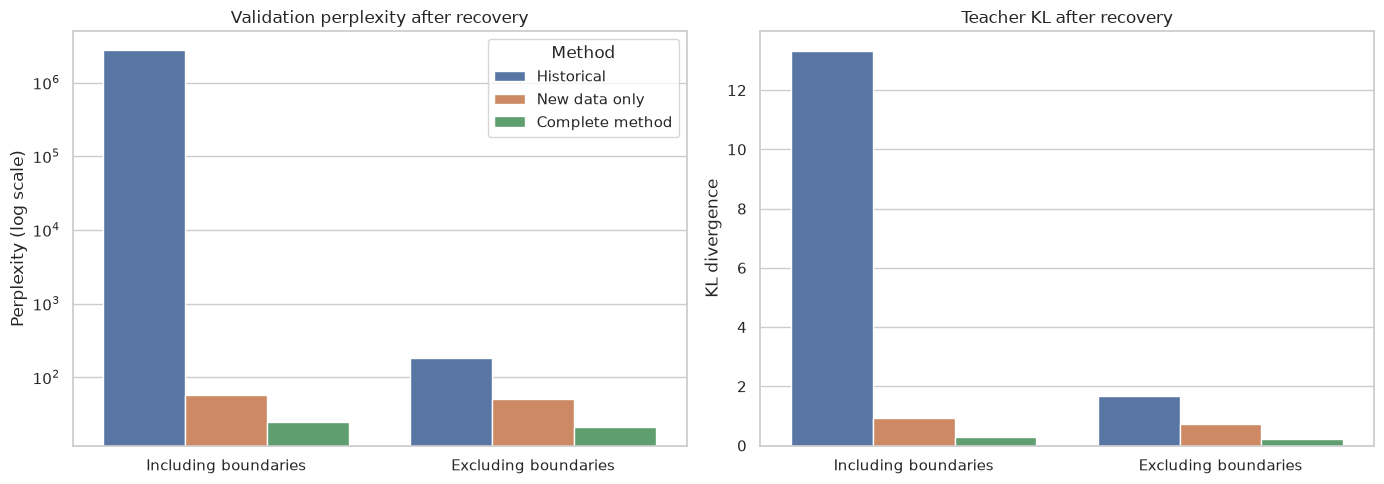

In [25]:
post_recovery_plot_data = comparison_evaluation_df.query(
    "stage == 'after_recovery'"
)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.barplot(
    data=post_recovery_plot_data,
    x='boundaries',
    y='perplexity',
    hue='method',
    hue_order=METHODOLOGY_ORDER,
    ax=axes[0],
)
axes[0].set_yscale('log')
axes[0].set_title('Validation perplexity after recovery')
axes[0].set_xlabel('')
axes[0].set_ylabel('Perplexity (log scale)')
sns.barplot(
    data=post_recovery_plot_data,
    x='boundaries',
    y='teacher_kl',
    hue='method',
    hue_order=METHODOLOGY_ORDER,
    ax=axes[1],
)
axes[1].set_title('Teacher KL after recovery')
axes[1].set_xlabel('')
axes[1].set_ylabel('KL divergence')
if axes[1].legend_ is not None:
    axes[1].legend_.remove()
axes[0].legend(title='Method')
fig.tight_layout()
plt.show()

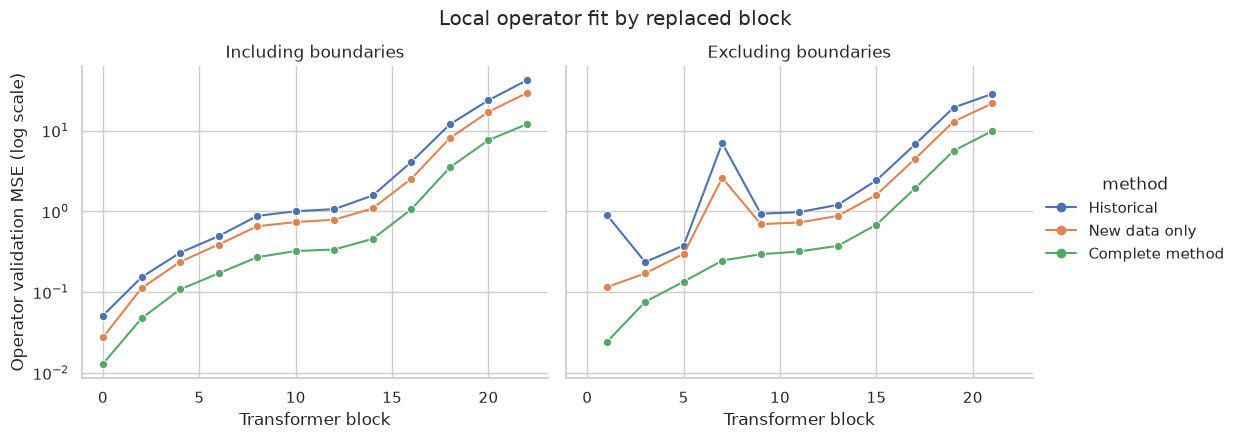

In [26]:
block_plot = sns.relplot(
    data=comparison_block_fitting_df,
    x='layer',
    y='validation_mse',
    hue='method',
    hue_order=METHODOLOGY_ORDER,
    col='boundaries',
    kind='line',
    marker='o',
    height=4.2,
    aspect=1.25,
)
block_plot.set(yscale='log')
block_plot.set_axis_labels(
    'Transformer block',
    'Operator validation MSE (log scale)',
)
block_plot.set_titles('{col_name}')
block_plot.figure.suptitle(
    'Local operator fit by replaced block',
    y=1.04,
)
plt.show()

artifact

In [27]:
if RUN_OPTIMIZED_FROM_SCRATCH:
    historical_calibration_pairs = (
        BASE_CALIBRATION_BATCHES
        * data_config.batch_size
        * data_config.sequence_length
    )
    optimized_calibration_pairs = (
        OPTIMIZED_CALIBRATION_BATCHES
        * optimized_data_config.batch_size
        * optimized_data_config.sequence_length
    )
    optimized_artifact = {
        'schema_version': OPTIMIZED_ARTIFACT_SCHEMA_VERSION,
        'created_at_utc': datetime.now(
            timezone.utc
        ).isoformat(),
        'environment': environment_record(),
        'configuration': {
            'model': {
                **json_value(optimized_model_config),
                'resolved_revision': getattr(
                    optimized_model.config,
                    '_commit_hash',
                    None,
                ),
            },
            'historical_control': {
                'artifact_path': str(ARTIFACT_PATH),
                'schema_version': (
                    historical_artifact['schema_version']
                ),
            },
            'methodologies': {
                'historical_random': {
                    'calibration_pairs': (
                        historical_calibration_pairs
                    ),
                    'initialization': 'random_weights',
                },
                'new_data_random': {
                    'calibration_pairs': (
                        optimized_calibration_pairs
                    ),
                    'initialization': 'random_weights',
                },
                'complete_method': {
                    'calibration_pairs': (
                        optimized_calibration_pairs
                    ),
                    'initialization': (
                        'importance_teacher_subset'
                    ),
                    'importance_metric': (
                        'rms_intermediate_activation_times_'
                        'down_projection_column_l2'
                    ),
                },
            },
            'partition_order': list(
                optimized_partition_batches
            ),
            'experiments': {
                methodology: {
                    variant: config.to_dict()
                    for variant, config in configs.items()
                }
                for methodology, configs
                in optimized_experiment_configs.items()
            },
        },
        'results': {
            'optimized_evaluations': json_records(
                optimized_evaluation_df
            ),
            'optimized_selections': json_records(
                optimized_selection_df
            ),
            'optimized_block_fitting': json_records(
                optimized_block_fitting_df
            ),
            'comparison_evaluations': json_records(
                comparison_evaluation_df
            ),
            'comparison_block_fitting': json_records(
                comparison_block_fitting_df
            ),
            'workflows': json_value(optimized_results),
        },
    }
    OPTIMIZED_ARTIFACT_PATH.parent.mkdir(
        parents=True,
        exist_ok=True,
    )
    OPTIMIZED_ARTIFACT_PATH.write_text(
        json.dumps(
            json_value(optimized_artifact),
            indent=2,
            allow_nan=False,
        ),
        encoding='utf-8',
    )
    print(
        f'Saved optimized compression artifact to '
        f'{OPTIMIZED_ARTIFACT_PATH}'
    )
else:
    print(
        f'Loaded optimized compression artifact from '
        f'{OPTIMIZED_ARTIFACT_PATH}'
    )

Saved optimized compression artifact to /home/sgulas/thesis/development/data/results/model-compression-baselines/compression-baseline-v2.json
